<a href="https://colab.research.google.com/github/VishnuDattu/Generative-AI/blob/main/GEN_AI_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install opencv-python matplotlib numpy

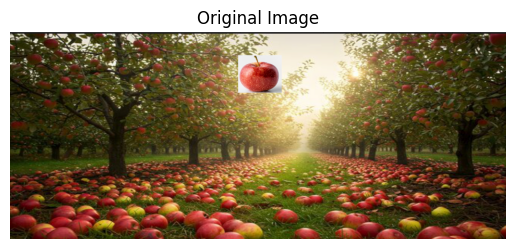

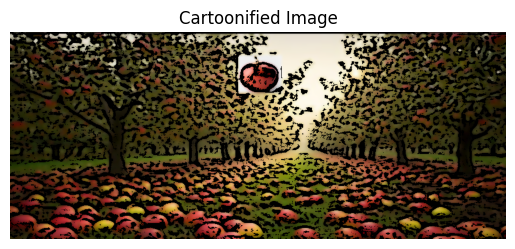

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Function to cartoonify an image
def cartoonify_image(image):
    # Apply bilateral filter to smooth the image
    color = cv2.bilateralFilter(image, d=9, sigmaColor=300, sigmaSpace=300)

    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Apply median blur
    gray = cv2.medianBlur(gray, 7)

    # Detect edges using adaptive thresholding
    edges = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                                   cv2.THRESH_BINARY, blockSize=9, C=2)

    # Combine color image with edges
    cartoon = cv2.bitwise_and(color, color, mask=edges)

    return cartoon

# Function to display the image
def display_image(image, title="Image"):
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()

# Load the human-like image
image_path = '/content/Screenshot 2026-02-10 200616.png'  # Change this to your image filename
image = cv2.imread(image_path)

if image is None:
    print(f"Error: Image not found at {image_path}")
else:
    # Display the original image
    display_image(image, title="Original Image")

    # Cartoonify the image
    cartoon_image = cartoonify_image(image)

    # Display the cartoonified image
    display_image(cartoon_image, title="Cartoonified Image")